# QAOA Workshop: Portfolio Optimization with Constraints

In this workshop, we will learn how to construct a **Quantum Approximate Optimization Algorithm (QAOA)** circuit using the Classiq platform's `phase` function, and how to execute it for solving a real-world combinatorial optimization problem — **Portfolio Optimization**.

We will progressively build up the solution:
1. **Part 1** — Portfolio optimization with **equality constraints** ($\sum_i w_i = B$)
2. **Part 2** — Portfolio optimization with **inequality constraints** ($\sum_i w_i \leq B$) using slack variables

By the end, you will understand how the `phase` function encodes a classical cost function into a quantum circuit, and how penalty terms enforce constraints in QAOA.

## Guidance for the workshop

**The `# TODO` or `# Your code` is there for you to do yourself.**

## Background: QAOA and the `phase` Function

The **Quantum Approximate Optimization Algorithm (QAOA)** is a hybrid quantum-classical algorithm for solving combinatorial optimization problems. The algorithm works by:

1. **Preparing an initial state** — a uniform superposition over all possible solutions using Hadamard gates.
2. **Applying alternating layers** of two operators:
   - **Cost layer**: Encodes the objective function as phase rotations on quantum states. States corresponding to better solutions accumulate more favorable phases.
   - **Mixer layer**: Applies $R_X$ rotations to explore the solution space.
3. **Optimizing parameters** — A classical optimizer tunes the angles ($\gamma$ for cost layers, $\beta$ for mixer layers) to maximize the probability of measuring optimal solutions.

### The `phase` function in Classiq

In the Classiq platform, the cost layer is implemented using the `phase` function. It takes:
- `phase_expr`: A classical expression (the cost function) that evaluates differently for each computational basis state.
- `coefficient`: A parameter $\gamma$ controlling the extent of the phase rotation.

The effect is:

$$|x\rangle \rightarrow e^{i \cdot \gamma \cdot f(x)} |x\rangle$$

where $f(x)$ is the cost function value for solution $x$. It is applied in the form of Hamiltonian $H$, which is elegantly converts a classical cost function into quantum phase rotations — the key ingredient of QAOA.

## Modeling the Portfolio Optimization Problem

We use a simple yet powerful model that captures the essence of portfolio optimization:

- A portfolio is built from a pool of $n$ financial assets, each labeled $i \in \{1,\ldots,n\}$.
- Every asset's return is a random variable with expected value $\mu_i$ and variance $\sigma_i$ (modeling financial risk).
- Every two assets $i \neq j$ have covariance $\sigma_{ij}$ (modeling market correlation).
- Every asset $i$ has a weight $w_i \in D_i = \{0,\ldots,b_i\}$ in the portfolio.

The total expected return is $\mu^T w$ and the total risk is $w^T \Sigma w$.

Our optimization problem is:

$$\min_{w \in D} \; w^T \Sigma w - \lambda \cdot \mu^T w$$

where $\lambda$ is a return coefficient that controls the risk-return tradeoff.

We will progressively add constraints:
- **Part 1**: Equality constraint $\sum_i w_i = B$ (exact budget)
- **Part 2**: Inequality constraint $\sum_i w_i \leq B$ (budget cap)

## Setup and Imports

In [ ]:
import classiq
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

from classiq import *

## Problem Parameters

We define a portfolio with 3 assets. Each asset can be allocated a weight from 0 to 3 (encoded with 2 qubits per asset).

In [3]:
authenticate()

/Users/miria/Documents/Quantum_hackathon/.venv/lib/python3.12/site-packages/classiq/_internals/authentication/token_manager.py:116: UserWarning: Device is already registered.
Generating a new refresh token should only be done if the current refresh token is compromised.
To do so, set the overwrite parameter to true
  warnings.warn(


In [6]:
DEMAND_COUNT = 5
NODES_COUNT = 10
PATHS_PER_DEMAND = 5

In [7]:
VARIABLES_COUNT = DEMAND_COUNT * PATHS_PER_DEMAND

demands = [[1, 3, 3], [1, 4, 4], [2, 5, 2], [3, 4, 1], [4, 5, 2]]

returns = np.ones(VARIABLES_COUNT)

# covariances = np.array(
#     [
#         [ 0.9,  0.5, -0.7],
#         [ 0.5,  0.9, -0.2],
#         [-0.7, -0.2,  0.9],
#     ]
# )

total_budget = 6

num_assets = 3
num_qubits_per_asset = 2

return_coeff = 1.5

a## Defining the Quantum Variables

We define a `QStruct` to hold our portfolio variables. Each asset weight is a `QNum` with `num_qubits_per_asset` qubits, allowing integer values from 0 to $2^{\text{num\_qubits\_per\_asset}} - 1$.

In [3]:
class PortfolioOptimizationVars(QStruct):
    a: QArray[QNum[num_qubits_per_asset], num_assets]

---

# Part 1: Portfolio Optimization with Equality Constraints

We will build up the cost function in two stages:
1. First, define the **base objective** (risk minus return) — the unconstrained form.
2. Then, add an **equality constraint** ($\sum_i w_i = B$) via a penalty term.

The QAOA circuit will use the final equality-constrained objective.

## Step 1: Define the Cost Function Components

### Expected Return: $\mu^T w$

Define a function that computes $\mu^T w$ where $\mu$ is the return vector.

In [4]:
def expected_return_cost(
    returns: np.ndarray, w_array: PortfolioOptimizationVars
) -> float:
    # Compute mu^T w = sum of returns[i] * w_array.a[i]
    
    return sum(returns[i] * w_array.a[i] for i in range(len(returns)))

### Risk Term: $w^T \Sigma w$

Define a function that computes $w^T \Sigma w$ where $\Sigma$ is the covariance matrix.

In [5]:
def risk_cost(covariances: np.ndarray, w_array: PortfolioOptimizationVars) -> float:
    #  Compute w^T Sigma w = sum_i sum_j w_i * Sigma_ij * w_j

    risk_term = sum(
        w_array.a[i]
        * sum(w_array.a[j] 
        * covariances[i][j] 
        for j in range(covariances.shape[0]))
        for i in range(covariances.shape[0])
    )

    return risk_term

### Base Objective (Unconstrained): $w^T \Sigma w - \lambda \cdot \mu^T w$

First, we define the unconstrained objective that combines risk and return. The `return_coeff` ($\lambda$) controls the risk-return tradeoff — higher values prioritize returns (more risky but potentially more profitable).

In [6]:
def objective_portfolio(
    w_array: PortfolioOptimizationVars,
    returns: np.ndarray,
    covariances: np.ndarray,
    return_coeff: float,
) -> float:
    # TODO: Combine risk_cost and expected_return_cost
    # objective = risk - return_coeff * expected_return
    # Your code here
    risk = risk_cost(covariances, w_array)
    expected_return = expected_return_cost(returns, w_array)

    return risk - return_coeff * expected_return

#### Function solution

In [ ]:
def objective_portfolio(
    w_array: PortfolioOptimizationVars,
    returns: np.ndarray,
    covariances: np.ndarray,
    return_coeff: float,
) -> float:
    # TODO: Combine risk_cost and expected_return_cost
    # objective = risk - return_coeff * expected_return

    return risk_cost(covariances, w_array) - return_coeff * expected_return_cost(
        returns, w_array
    )

### Adding the Equality Constraint: $\sum_i w_i = B$

In practice, we need to invest **exactly** a total budget $B$. To enforce this in QAOA, we add a **quadratic penalty term** to the objective:

$$\min_{w \in D} \; w^T \Sigma w - \lambda \cdot \mu^T w + P \cdot \left(\sum_i w_i - B\right)^2$$

The penalty term $P \cdot (\sum_i w_i - B)^2$ is:
- **Zero** when the constraint is satisfied ($\sum_i w_i = B$)
- **Positive** when violated, pushing the optimizer toward feasible solutions

The penalty coefficient $P$ must be large enough to discourage infeasible solutions, but not so large that it dominates the objective. This is the standard approach for encoding equality constraints in QAOA — it transforms a constrained problem into an unconstrained one that the `phase` function can handle directly.

In [8]:
Penalty = 2.0


def objective_portfolio_equality(
    w_array: PortfolioOptimizationVars,
    returns: np.ndarray,
    covariances: np.ndarray,
    return_coeff: float,
) -> float:
    # TODO: Add a penalty term for the equality constraint sum(w_i) == total_budget
    # objective = risk - return_coeff * expected_return + Penalty * (sum(w_i) - B)^2
    # Your code here
    risk = risk_cost(covariances, w_array)
    expected_return = expected_return_cost(returns, w_array)
    equality_term = (sum(w_array.a[i] for i in range(len(returns))) - total_budget)**2

    return risk - return_coeff * expected_return + Penalty * equality_term

### Function Solution

In [ ]:
Penalty = 2.0


def objective_portfolio_equality(
    w_array: PortfolioOptimizationVars,
    returns: np.ndarray,
    covariances: np.ndarray,
    return_coeff: float,
) -> float:
    # TODO: Add a penalty term for the equality constraint sum(w_i) == total_budget
    # objective = risk - return_coeff * expected_return + Penalty * (sum(w_i) - B)^2
    

    return (
        risk_cost(covariances, w_array)
        - return_coeff * expected_return_cost(returns, w_array)
        + Penalty
        * (sum(w_array.a[i] for i in range(len(returns))) - total_budget) ** 2
    )
  

## Step 2: Build the QAOA Circuit

### Mixer Layer

The mixer layer applies $R_X(\beta)$ rotations to all qubits, allowing the algorithm to explore different solutions.

In [9]:
@qfunc
def mixer_layer(beta: CReal, qba: QArray):
    # Apply RX(beta) to all qubits using apply_to_all
    
    apply_to_all(lambda q: RX(beta, q), qba)
    # Alternatively, you can use for loop/repeat

### Main QAOA Ansatz

The `main` function builds the full QAOA circuit:
1. **Allocate** qubits for the portfolio variables
2. **Hadamard transform** — creates uniform superposition (initial state)
3. **Repeat** for each layer:
   - Apply the **cost layer** using `phase(objective, gamma)`
   - Apply the **mixer layer** using `mixer_layer(beta)`

This is where the `phase` function does its magic — it converts our classical objective function into quantum phase rotations automatically!

In [10]:
NUM_LAYERS = 4


@qfunc
def main(
    params: CArray[CReal, 2 * NUM_LAYERS], w_array: Output[PortfolioOptimizationVars]
) -> None:
    # TODO:
    # 1. Allocate qubits: allocate(w_array)
    # 2. Apply Hadamard transform: hadamard_transform(w_array)
    # 3. Repeat NUM_LAYERS times, alternating:
    #    - phase(objective_portfolio_equality(...), params[2*i])  <-- cost layer
    #    - mixer_layer(params[2*i+1], w_array)                   <-- mixer layer
    # Your code here

    allocate(w_array)

    hadamard_transform(w_array)
    
    repeat(
        count=NUM_LAYERS,
        iteration=lambda i: (
            phase(
                phase_expr=objective_portfolio_equality(w_array, returns, covariances, return_coeff),
                coefficient=params[2 * i],
            ),
            mixer_layer(params[2 * i + 1], w_array),
        ), # here we combine 2 functions in the iteration: phase & mixer_layer
    )
    

## Function solution

In [ ]:
NUM_LAYERS = 4


@qfunc
def main(
    params: CArray[CReal, 2 * NUM_LAYERS], w_array: Output[PortfolioOptimizationVars]
) -> None:
    # TODO:
    # 1. Allocate qubits: allocate(w_array)
    # 2. Apply Hadamard transform: hadamard_transform(w_array)
    # 3. Repeat NUM_LAYERS times, alternating:
    #    - phase(objective_portfolio_equality(...), params[2*i])  <-- cost layer
    #    - mixer_layer(params[2*i+1], w_array)                   <-- mixer layer
  

    allocate(w_array)

    hadamard_transform(w_array)
    
    repeat(
        count=int(params.len / 2),
        iteration=lambda i: (
            phase(
                objective_portfolio_equality(
                    w_array, returns, covariances, return_coeff
                ),
                params[2 * i],
            ),
            mixer_layer(params[2 * i + 1], w_array),
        ),
    )
    

## Step 3: Synthesize and Visualize

In [11]:
qprog = synthesize(main)
show(qprog)

HTTP POST /api/v22/tasks/generate/upload-url failed
Traceback (most recent call last):
  File "/Users/miria/Documents/Quantum_hackathon/.venv/lib/python3.12/site-packages/classiq/_internals/client.py", line 264, in _request_attempt
    self.handle_response(response)
  File "/Users/miria/Documents/Quantum_hackathon/.venv/lib/python3.12/site-packages/classiq/_internals/client.py", line 139, in handle_response
    self._handle_error(response)
  File "/Users/miria/Documents/Quantum_hackathon/.venv/lib/python3.12/site-packages/classiq/_internals/client.py", line 157, in _handle_error
    raise ClassiqExpiredTokenError("Expired token")
classiq.interface.exceptions.ClassiqExpiredTokenError: Expired token
If you need further assistance, please reach out on our Community Slack channel at: https://short.classiq.io/join-slack or open a support ticket at: https://classiq-community.freshdesk.com/support/tickets/new


Quantum program link: https://platform.classiq.io/circuit/3IlqEnFgEC6zF1WmiU1E5YdqXDB


## Step 4: Execute and Optimize

### Setting up the Execution Session

We use `ExecutionSession` for hybrid classical-quantum execution. The `estimate_cost` method samples the circuit and returns the average cost — this is what the classical optimizer will minimize.

In [12]:
NUM_SHOTS = 1000

es = ExecutionSession(
    qprog, execution_preferences=ExecutionPreferences(num_shots=NUM_SHOTS)
)

### Initial Parameters

A good initialization for QAOA is a linear schedule: $\gamma$ values go from $0 \to \pi$ and $\beta$ values go from $\pi \to 0$. This mimics an adiabatic evolution with discrete steps.

In [13]:
# Build initial_params as interleaved [gamma_0, beta_0, gamma_1, beta_1, ...]
# gammas: linearly from 0 to 1
# betas: linearly from 1 to 0



def initial_qaoa_params(num_layers) -> np.ndarray:
    initial_gammas = np.linspace(0, 1, num_layers)
    initial_betas = np.linspace(1, 0, num_layers)

    initial_params = []
    for i in range(num_layers):
        initial_params.append(initial_gammas[i])
        initial_params.append(initial_betas[i])

    return np.array(initial_params)



initial_params = initial_qaoa_params(NUM_LAYERS)

### Define the Cost Function and Optimizer

In [14]:
intermediate_params = []
objective_values = []


def callback(xk):
    intermediate_params.append(xk)


# Define cost_func that takes a sampled state and returns the objective value
# Then define estimate_cost_func that uses es.estimate_cost to evaluate the circuit
# Your code here


cost_func = lambda state: objective_portfolio_equality(
    w_array=state["w_array"],
    returns=returns,
    covariances=covariances,
    return_coeff=return_coeff,
)


def estimate_cost_func(params: np.ndarray) -> float:
    objective_value = es.estimate_cost(
        cost_func=cost_func, parameters={"params": params.tolist()}
    )
    objective_values.append(objective_value)
    return objective_value



### Run the Classical Optimization

In [15]:
optimization_res = minimize(
    fun=estimate_cost_func,
    x0=initial_params,
    method="COBYLA",
    callback=callback,
    options={"maxiter": 30},
)

## Step 5: Analyze the Results

In [16]:
res = es.sample({"params": optimization_res.x.tolist()})

print(f"Optimized parameters: {optimization_res.x.tolist()}\n")

sorted_counts = sorted(
    res.parsed_counts,
    key=lambda pc: objective_portfolio_equality(
        pc.state["w_array"],
        returns=returns,
        covariances=covariances,
        return_coeff=return_coeff,
    ),
)

print("Top 10 solutions (equality constraint: sum(w_i) == B):")
for sampled in sorted_counts[:10]:
    w_sample = sampled.state["w_array"]
    w_sum = sum(w_sample["a"][i] for i in range(num_assets))
    cost = objective_portfolio_equality(
        w_array=w_sample,
        returns=returns,
        covariances=covariances,
        return_coeff=return_coeff,
    )
    feasible = "  ✓" if w_sum == total_budget else "  ✗"
    print(
        f"  weights={w_sample} | sum={w_sum} | prob={sampled.shots/NUM_SHOTS:.3f} | cost={cost:.4f}{feasible}"
    )

Optimized parameters: [-0.014349622544693017, 0.9792693517057709, 0.3118287844678014, 0.6491825304143761, 0.6569550983783932, 1.3026197579275953, 2.012097210816162, 0.9946721484757532]

Top 10 solutions (equality constraint: sum(w_i) == B):
  weights={'a': [2, 2, 2]} | sum=6 | prob=0.017 | cost=-10.4000  ✓
  weights={'a': [3, 1, 2]} | sum=6 | prob=0.025 | cost=-10.1000  ✓
  weights={'a': [3, 2, 2]} | sum=7 | prob=0.038 | cost=-9.2000  ✗
  weights={'a': [1, 3, 2]} | sum=6 | prob=0.094 | cost=-9.1000  ✓
  weights={'a': [2, 2, 1]} | sum=5 | prob=0.014 | cost=-9.0000  ✗
  weights={'a': [2, 3, 2]} | sum=7 | prob=0.001 | cost=-8.7000  ✗
  weights={'a': [1, 3, 1]} | sum=5 | prob=0.001 | cost=-8.7000  ✗
  weights={'a': [3, 1, 1]} | sum=5 | prob=0.030 | cost=-7.7000  ✗
  weights={'a': [3, 3, 1]} | sum=7 | prob=0.027 | cost=-7.3000  ✗
  weights={'a': [2, 3, 0]} | sum=5 | prob=0.006 | cost=-7.3000  ✗


Closing `ExecutionSession` 

In [ ]:
es.close()

### Convergence Graph

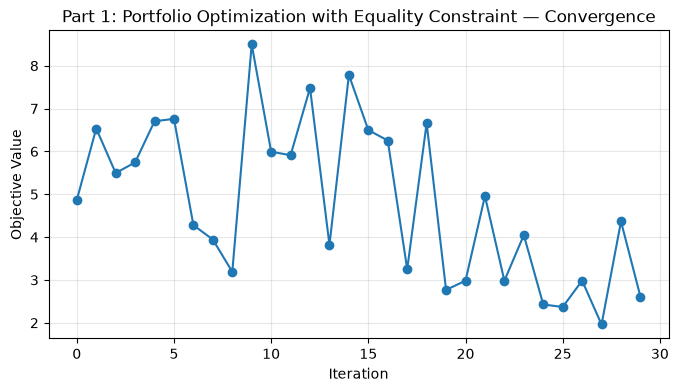

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(objective_values, "o-")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Part 1: Portfolio Optimization with Equality Constraint — Convergence")
plt.grid(True, alpha=0.3)
plt.show()

---

# Part 2: Adding Inequality Constraints

$$\min_{w \in D} \; w^T \Sigma w - \lambda \cdot \mu^T w \quad \text{subject to} \quad \sum_i w_i \leq B$$

For inequality constraints, we use the **slack variable** technique. The idea:

- An inequality $\sum_i w_i \leq B$ can be rewritten as an equality: $\sum_i w_i + \text{slack} = B$
- The slack variable is a non-negative integer that absorbs the "gap" between the actual sum and the budget
- We then apply the same penalty approach as Part 1:

$$\min_{w \in D} \; w^T \Sigma w - \lambda \cdot \mu^T w + P \cdot \left(\sum_i w_i + \text{slack} - B\right)^2$$

The slack variable requires additional qubits. The number of slack qubits determines the range of slack values ($0$ to $2^{\text{num\_slack}} - 1$).

## Redefine the Quantum Variables with Slack

In [18]:
num_slack = 3


class PortfolioOptimizationVarsWithSlack(QStruct):
    a: QArray[QNum[num_qubits_per_asset], num_assets]
    slack: QNum[num_slack]

## Define the Cost Functions for Inequality

We reuse `expected_return_cost` and `risk_cost` but adapt them for the new struct. The key difference is adding the slack variable to the constraint penalty term.

In [19]:
def expected_return_cost_ineq(
    returns: np.ndarray, w_array: PortfolioOptimizationVarsWithSlack
) -> float:
    return sum(returns[i] * w_array.a[i] for i in range(len(returns)))


def risk_cost_ineq(
    covariances: np.ndarray, w_array: PortfolioOptimizationVarsWithSlack
) -> float:
    return sum(
        w_array.a[i]
        * sum(w_array.a[j] * covariances[i][j] for j in range(covariances.shape[0]))
        for i in range(covariances.shape[0])
    )


Penalty_ineq = 1.3


def objective_portfolio_inequality(
    w_array: PortfolioOptimizationVarsWithSlack,
    returns: np.ndarray,
    covariances: np.ndarray,
    return_coeff: float,
) -> float:
    # Same as equality, but add w_array.slack to the constraint sum
    # objective = risk - return_coeff * return + Penalty * (sum(w_i) + slack - B)^2


    return (
        risk_cost_ineq(covariances, w_array)
        - return_coeff * expected_return_cost_ineq(returns, w_array)
        + Penalty_ineq
        * (
            sum(w_array.a[i] for i in range(len(returns)))
            + w_array.slack
            - total_budget
        )
        ** 2
    )
   

## Build and Synthesize the QAOA Circuit with Inequality Constraint

In [20]:
@qfunc
def main(
    params: CArray[CReal, 2 * NUM_LAYERS],
    w_array: Output[PortfolioOptimizationVarsWithSlack],
) -> None:
    # TODO: Build the QAOA circuit using objective_portfolio_inequality
    # Same structure as before, but now w_array includes the slack variable
   
    allocate(w_array)
    hadamard_transform(w_array)

    repeat(
        count=int(params.len / 2),
        iteration=lambda i: (
            phase(
                objective_portfolio_inequality(
                    w_array, returns, covariances, return_coeff
                ),
                params[2 * i],
            ),
            mixer_layer(params[2 * i + 1], w_array),
        ),
    )
   


qprog_ineq = synthesize(main)
show(qprog_ineq)

Quantum program link: https://platform.classiq.io/circuit/3Ilu69RGnExqVjF5YeDA6sHyMyJ


## Execute and Optimize (Inequality)

In [21]:
es_ineq = ExecutionSession(
    qprog_ineq, execution_preferences=ExecutionPreferences(num_shots=NUM_SHOTS)
)

initial_params_ineq = initial_qaoa_params(NUM_LAYERS)

intermediate_params_ineq = []


def callback_ineq(xk):
    intermediate_params_ineq.append(xk)

objective_values_ineq = []




cost_func_ineq = lambda state: objective_portfolio_inequality(
    w_array=state["w_array"],
    returns=returns,
    covariances=covariances,
    return_coeff=return_coeff,
)


def estimate_cost_func_ineq(params: np.ndarray) -> float:
    objective_value = es_ineq.estimate_cost(
        cost_func=cost_func_ineq, parameters={"params": params.tolist()}
    )
    objective_values_ineq.append(objective_value)
    return objective_value


optimization_res_ineq = minimize(
    fun=estimate_cost_func_ineq,
    x0=initial_params_ineq,
    method="COBYLA",
    callback=callback_ineq,
    options={"maxiter": 45},
)

ConnectTimeout: 

## Results (Inequality Constraint)

For inequality-constrained results, feasible solutions satisfy $\sum_i w_i \leq B$. The slack variable absorbs the difference — when `slack > 0`, it means the portfolio uses less than the full budget.

In [ ]:
res_ineq = es_ineq.sample({"params": optimization_res_ineq.x.tolist()})

sorted_counts_ineq = sorted(
    res_ineq.parsed_counts,
    key=lambda pc: objective_portfolio_inequality(
        pc.state["w_array"],
        returns=returns,
        covariances=covariances,
        return_coeff=return_coeff,
    ),
)

print("Top 15 solutions (inequality constraint: sum(w_i) <= B):")
for sampled in sorted_counts_ineq[:15]:
    w_sample = sampled.state["w_array"]
    w_sum = sum(w_sample["a"][i] for i in range(num_assets))
    slack_val = w_sample["slack"]
    cost = objective_portfolio_inequality(
        w_array=w_sample,
        returns=returns,
        covariances=covariances,
        return_coeff=return_coeff,
    )
    feasible = "  ✓" if w_sum <= total_budget else "  ✗"
    print(
        f"  weights={w_sample['a']} | slack={slack_val} | sum={w_sum} | "
        f"prob={sampled.shots/NUM_SHOTS:.3f} | cost={cost:.4f}{feasible}"
    )

### Closing session

In [ ]:
es_ineq.close()

### Convergence Graph (Inequality)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(objective_values_ineq, "o-")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Part 3: Inequality Constraint — Convergence")
plt.grid(True, alpha=0.3)
plt.show()

---

# Alternative: Pyomo-Based QAOA with `CombinatorialProblem`

Instead of manually building the cost function and QAOA circuit with `phase`, Classiq provides a higher-level interface using **Pyomo** models and `CombinatorialProblem`. This automatically translates the optimization model (including constraints) into a QAOA circuit.

In [ ]:
import pyomo.core as pyo
from classiq.applications.combinatorial_optimization import CombinatorialProblem

portfolio_model = pyo.ConcreteModel("portfolio_optimization")

portfolio_model.w = pyo.Var(range(num_assets), domain=pyo.Integers, bounds=(0, 3))

w_array = list(portfolio_model.w.values())

portfolio_model.budget_rule = pyo.Constraint(expr=(sum(w_array) <= total_budget))

portfolio_model.expected_return = returns @ w_array
portfolio_model.risk = w_array @ covariances @ w_array

portfolio_model.cost = pyo.Objective(
    expr=portfolio_model.risk - portfolio_model.expected_return, sense=pyo.minimize
)

combi = CombinatorialProblem(pyo_model=portfolio_model, num_layers=3, penalty_factor=10)

qprog_pyomo = combi.get_qprog()
show(qprog_pyomo)

---

# Summary

In this workshop we learned:

1. **QAOA structure**: Hadamard initialization → alternating cost/mixer layers → classical optimization of parameters.
2. **The `phase` function**: Converts a classical objective function into quantum phase rotations. You only need to define the cost function arithmetically — Classiq handles the quantum circuit construction.
3. **Constraint handling via penalties**:
   - **Equality** ($\sum w_i = B$): Add penalty $P \cdot (\sum w_i - B)^2$
   - **Inequality** ($\sum w_i \leq B$): Introduce a slack variable and add penalty $P \cdot (\sum w_i + \text{slack} - B)^2$

| Aspect | Equality (Part 1) | Inequality (Part 2) |
|--------|:---:|:---:|
| Objective | $w^T\Sigma w - \lambda\mu^T w + P(\sum w_i - B)^2$ | $w^T\Sigma w - \lambda\mu^T w + P(\sum w_i + s - B)^2$ |
| Extra qubits | None | Slack variable |
| Constraint type | $\sum w_i = B$ | $\sum w_i \leq B$ |

## Things to Try

1. **Change `return_coeff`**: Higher values prioritize returns over risk. How does this affect the optimal portfolio?
2. **Change `Penalty`**: What happens if the penalty is too small? Too large?
3. **Change `NUM_LAYERS`**: More layers generally improve solution quality but increase circuit depth.
4. **Change the optimizer**: Try `"COBYLA"`, `"Nelder-Mead"`, `"L-BFGS-B"`, or `"BFGS"` from `scipy.optimize.minimize`.
5. **Change `num_qubits_per_asset`**: Increasing from 2 to 3 allows weights 0-7 instead of 0-3.

## References

- [Farhi, Edward, Jeffrey Goldstone, and Sam Gutmann. "A quantum approximate optimization algorithm." arXiv:1411.4028 (2014).](https://arxiv.org/abs/1411.4028)
- [Classiq Documentation: QAOA](https://docs.classiq.io/latest/explore/algorithms/search_and_optimization/QAOA/qaoa)
- [Classiq Documentation: Portfolio Optimization](https://docs.classiq.io/latest/explore/applications/finance/portfolio_optimization/portfolio_optimization)